# P04：替换动力学骨干网络

将 P02 的 RSSM 替换为因果 Transformer，并在相同合成数据上对两种骨干网络进行对比。本教程聚焦于工程权衡：RSSM 具有更强的归纳偏置，而注意力机制则更易于并行化，并对长上下文具有更强的灵活性。整体流程包括：类别 VAE（CatVAE）tokenization、因果 Transformer 训练，以及与 RSSM 的 rollout 对比，这是一次受控对比，而非声称 Transformer 在一般情况下更优。

**前置条件**：若存在 P02 的权重文件（`rssm.pt`），则直接加载；否则将使用随机初始化的 RSSM 作为回退，notebook 仍可正常运行，但此时 RSSM 与 Transformer 的数值比较仅具有参考意义，而非基于预训练权重的有效对比。本 notebook 从头训练 CatVAE 和 Transformer，并将结果保存至 `transformer_wm.pt`，供 P05 使用。

> Notebook 源文件: [p04_transformer_backbone.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/zh/projects/p04_transformer_backbone.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


依赖已经准备好，先导入核心库并统一运行时设置，让 VAE 和 Transformer 两部分共用同一个运行环境。

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from pathlib import Path

# 让 Colab 和新环境优先使用支持中文的字体，避免标题和坐标轴显示成方框。
def _configure_cjk_font():
    preferred = [
        "Noto Sans CJK SC",
        "Noto Sans SC",
        "Source Han Sans SC",
        "Microsoft YaHei",
        "SimHei",
        "PingFang SC",
        "WenQuanYi Micro Hei",
    ]
    for family in preferred:
        try:
            font_manager.findfont(family, fallback_to_default=False)
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [family] + [f for f in mpl.rcParams.get("font.sans-serif", []) if f != family]
            mpl.rcParams["axes.unicode_minus"] = False
            return family
        except Exception:
            pass

    font_path = Path.home() / ".cache" / "notebook-fonts" / "NotoSansCJKsc-Regular.otf"
    if not font_path.exists():
        try:
            import urllib.request
            font_path.parent.mkdir(parents=True, exist_ok=True)
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
            urllib.request.urlretrieve(url, font_path)
        except Exception:
            font_path = None

    if font_path and font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        family = font_manager.FontProperties(fname=str(font_path)).get_name()
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [family] + [f for f in preferred if f != family]
        mpl.rcParams["axes.unicode_minus"] = False
        return family

    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    mpl.rcParams["axes.unicode_minus"] = False
    return None

_CJK_FONT = _configure_cjk_font()
import time
import os
import math

torch.manual_seed(42)
np.random.seed(42)
try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE

IS_ROCM = USE_CUDA and torch.version.hip is not None


def _is_rocm_radeon():
    if not IS_ROCM:
        return False
    try:
        arch = torch.cuda.get_device_properties(0).gcnArchName.split(':')[0]
    except Exception:
        return False
    return arch.startswith(('gfx10', 'gfx11', 'gfx12'))


IS_ROCM_RADEON = _is_rocm_radeon()


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

PATH = Path('.')
print('Device:', DEVICE)
if USE_TPU:
    print('TPU backend    : torch_xla')
print('PyTorch version:', torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu128


## 1. 类别 VAE

将每一帧 tokenize 为单个 32 维的离散编码。

正在生成 1000 张合成图形图像...
图像张量形状： torch.Size([1000, 3, 64, 64])   dtype: torch.float32


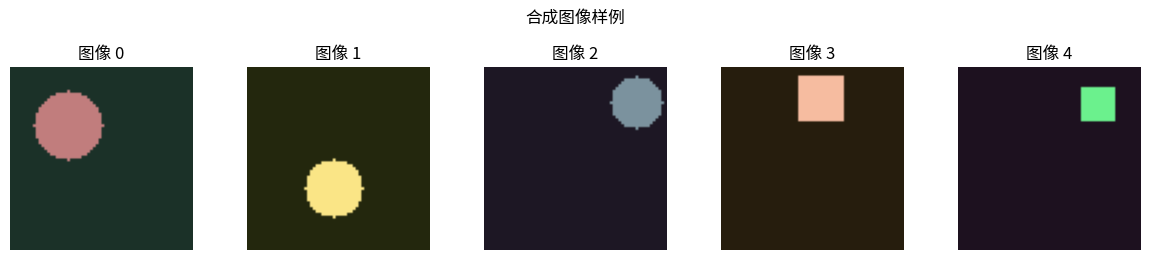

In [3]:
# 合成图形图像数据集。
def make_shape_images(n=1000, size=64, seed=0):
    rng = np.random.RandomState(seed)
    imgs = np.zeros((n, 3, size, size), dtype=np.float32)
    for i in range(n):
        # 背景
        bg = rng.uniform(0.05, 0.2, (3, 1, 1)).astype(np.float32)
        imgs[i] = bg
        # 随机形状：圆形或矩形
        color = rng.uniform(0.4, 1.0, 3).astype(np.float32)
        cx = rng.randint(10, size - 10)
        cy = rng.randint(10, size - 10)
        r = rng.randint(5, 14)
        shape_type = rng.randint(0, 2)
        for c in range(3):
            if shape_type == 0:  # 圆形
                for y in range(size):
                    for x in range(size):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                            imgs[i, c, y, x] = color[c]
            else:  # 矩形
                x0, x1 = max(0, cx - r), min(size, cx + r)
                y0, y1 = max(0, cy - r), min(size, cy + r)
                imgs[i, c, y0:y1, x0:x1] = color[c]
    return torch.from_numpy(imgs)

print('正在生成 1000 张合成图形图像...')
images = make_shape_images(n=1000, size=64, seed=42)
print('图像张量形状：', images.shape, '  dtype:', images.dtype)

# 快速健全性检查
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ax.axis('off')
    ax.set_title(f'图像 {i}')
plt.suptitle('合成图像样例', y=1.02)
plt.tight_layout()
plt.show()

合成形状数据就位后，先定义直通 Gumbel-softmax 近似，让 categorical VAE 可以端到端训练。

In [4]:
# 直通 Gumbel-softmax。
def straight_through_gumbel(logits, tau=1.0):
    """返回离散采样的直通（straight-through）估计器。"""
    y_soft = F.gumbel_softmax(logits, tau=tau, hard=False)
    y_hard = F.one_hot(y_soft.argmax(-1), num_classes=logits.shape[-1]).float()
    # 直通：前向使用 y_hard，反向梯度流经 y_soft
    return (y_hard - y_soft).detach() + y_soft


# --- 类别 VAE ---
NUM_CATEGORIES = 32   # 离散词表大小
Z_DIM = 32            # 每个 token 的嵌入维度

class CatVAEEncoder(nn.Module):
    """将 3x64x64 帧映射为 NUM_CATEGORIES 类别 logits 的 CNN。"""
    def __init__(self, num_categories=NUM_CATEGORIES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 4x4
            nn.ReLU(),
            nn.Flatten(),                 # 256*4*4 = 4096
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_categories),
        )

    def forward(self, x):
        return self.net(x)  # (B, num_categories)


class CatVAEDecoder(nn.Module):
    """将 32 维 one-hot 嵌入解码回 3x64x64 的 MLP + ConvTranspose。"""
    def __init__(self, num_categories=NUM_CATEGORIES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_categories, 256),
            nn.ReLU(),
            nn.Linear(256, 256 * 4 * 4),
            nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # 64x64
            nn.Sigmoid(),
        )

    def forward(self, z_onehot):
        h = self.fc(z_onehot)
        h = h.view(-1, 256, 4, 4)
        return self.deconv(h)  # (B, 3, 64, 64)


class CatVAE(nn.Module):
    def __init__(self, num_categories=NUM_CATEGORIES, tau=1.0):
        super().__init__()
        self.encoder = CatVAEEncoder(num_categories)
        self.decoder = CatVAEDecoder(num_categories)
        self.tau = tau

    def encode(self, x):
        """返回直通 one-hot 向量和 argmax 类别索引。"""
        logits = self.encoder(x)           # (B, K)
        z = straight_through_gumbel(logits, tau=self.tau)  # (B, K)
        idx = logits.argmax(-1)            # (B,)
        return z, idx, logits

    def forward(self, x):
        z, idx, logits = self.encode(x)
        recon = self.decoder(z)
        return recon, z, idx, logits

catvae = CatVAE(num_categories=NUM_CATEGORIES, tau=1.0).to(DEVICE)
total_params = sum(p.numel() for p in catvae.parameters())
print(f'CatVAE 参数量：{total_params:,}')

CatVAE 参数量：3,498,211


松弛形式准备好后，就直接在合成图像上训练 CatVAE，让离散潜变量学到紧凑表示。

正在训练 CatVAE...
  轮次  10/30  recon_loss=0.0265
  轮次  20/30  recon_loss=0.0260
  轮次  30/30  recon_loss=0.0259
CatVAE 训练完成。


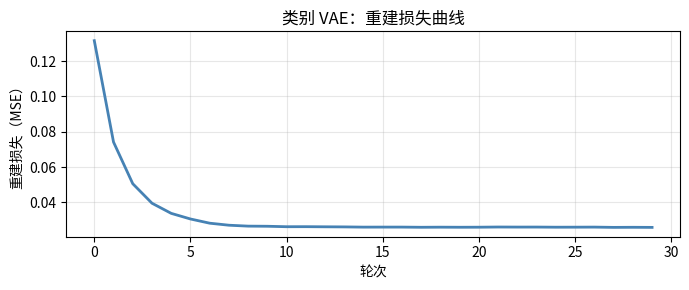

In [5]:
# 训练 CatVAE。
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(images)
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0 if USE_TPU else 2, pin_memory=USE_CUDA)

opt_vae = torch.optim.Adam(catvae.parameters(), lr=3e-4)

VAE_EPOCHS = 30
vae_losses = []

print('正在训练 CatVAE...')
for epoch in range(VAE_EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        recon, z, idx, logits = catvae(batch)
        # 重建损失
        recon_loss = F.mse_loss(recon, batch)
        # 熵正则化：鼓励均匀使用各类别
        probs = F.softmax(logits, dim=-1).mean(0)  # (K,)
        entropy_reg = (probs * (probs + 1e-8).log()).sum()  # 负熵
        loss = recon_loss + 0.01 * entropy_reg
        opt_vae.zero_grad()
        loss.backward()
        optimizer_step(opt_vae)
        epoch_loss += recon_loss.item()
    vae_losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f'  轮次 {epoch+1:3d}/{VAE_EPOCHS}  recon_loss={vae_losses[-1]:.4f}')

print('CatVAE 训练完成。')

plt.figure(figsize=(7, 3))
plt.plot(vae_losses, linewidth=2, color='steelblue')
plt.xlabel('轮次')
plt.ylabel('重建损失（MSE）')
plt.title('类别 VAE：重建损失曲线')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

训练开始后，先做一次重建检查，确认类别瓶颈没有把图像结构压坏。

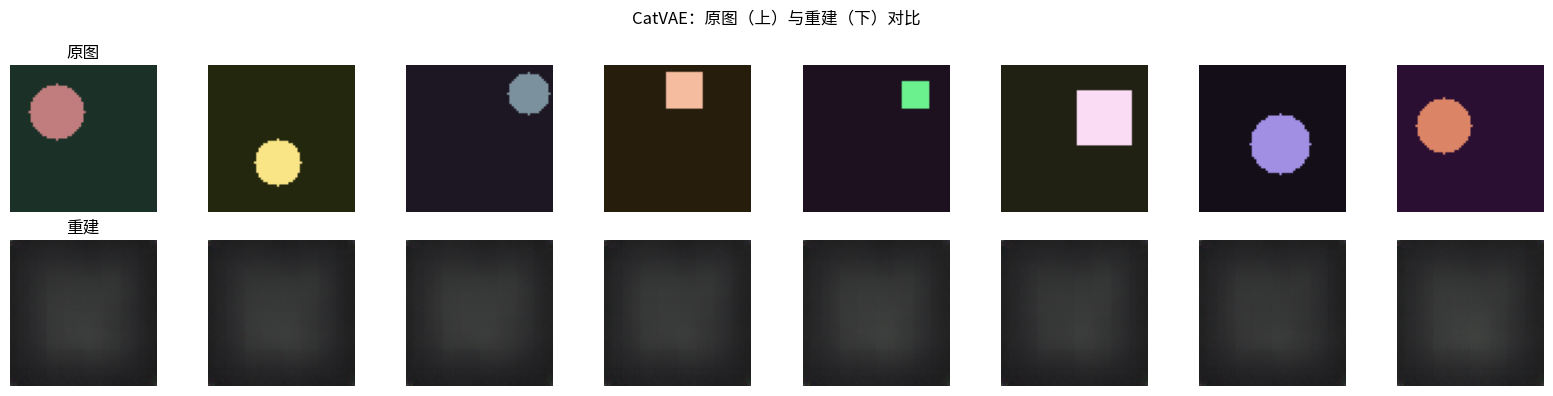

CatVAE(
  (encoder): CatVAEEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=4096, out_features=256, bias=True)
      (10): ReLU()
      (11): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): CatVAEDecoder(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4096, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
     

In [6]:
# 可视化 CatVAE 重建效果。
catvae.eval()
with torch.no_grad():
    sample = images[:8].to(DEVICE)
    recon, _, _, _ = catvae(sample)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title('原图' if i == 0 else '')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    axes[1, i].set_title('重建' if i == 0 else '')
plt.suptitle('CatVAE：原图（上）与重建（下）对比')
plt.tight_layout()
plt.show()
catvae.train()

## 2. 因果 Transformer

通过因果注意力预测未来 token 和奖励。

世界模型 Transformer 在交错的 (z, a) token 序列上运行。在每个时间步 t：
- z_t 是时间步 t 处观测的 CatVAE 编码（32 维 one-hot）
- a_t 是动作嵌入（2 个离散动作，投影至 32 维）

因果掩码保证位置 t 只能注意到位置 t 及其之前的位置，从而在训练时防止模型窥视未来观测。

位置 t 的输出预测以下内容：下一个离散潜在 token z_{t+1}（交叉熵）、奖励 r_t（MSE），以及结束标志 d_t（BCE）。

In [7]:
# 因果 Transformer 世界模型。
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
SEQ_LEN = 20   # 轨迹长度
N_ACTIONS = 2


# On ROCm Radeon (RDNA) the fused native_layer_norm_backward kernel can emit
# non-finite gradients; a primitive decomposition avoids that kernel.
class DecomposedLayerNorm(nn.Module):
    def __init__(self, ref):
        super().__init__()
        self.normalized_shape = tuple(ref.normalized_shape)
        self.eps = ref.eps
        self.weight = nn.Parameter(ref.weight.detach().clone())
        self.bias = nn.Parameter(ref.bias.detach().clone())

    def forward(self, x):
        dims = tuple(range(x.dim() - len(self.normalized_shape), x.dim()))
        mean = x.mean(dim=dims, keepdim=True)
        var = x.var(dim=dims, unbiased=False, keepdim=True)
        return (x - mean) / torch.sqrt(var + self.eps) * self.weight + self.bias


def _decompose_layernorms(module):
    for name, child in module.named_children():
        if isinstance(child, nn.LayerNorm):
            setattr(module, name, DecomposedLayerNorm(child))
        else:
            _decompose_layernorms(child)


class CausalTransformerWM(nn.Module):
    def __init__(self, num_categories=NUM_CATEGORIES, d_model=D_MODEL,
                 n_heads=N_HEADS, n_layers=N_LAYERS, n_actions=N_ACTIONS,
                 max_len=SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.num_categories = num_categories

        # 将 z（one-hot）和动作投影到 d_model 维
        self.z_proj = nn.Linear(num_categories, d_model)
        self.a_embed = nn.Embedding(n_actions, d_model)

        # 位置编码
        pos = torch.arange(max_len * 2).unsqueeze(1)  # *2 用于 (z,a) 交错
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len * 2, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

        # 使用 nn.MultiheadAttention 的 Transformer 层
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads,
                dim_feedforward=d_model * 4,
                batch_first=True, norm_first=True
            )
            for _ in range(n_layers)
        ])

        # 输出头
        self.token_head = nn.Linear(d_model, num_categories)   # 下一 token 预测
        self.reward_head = nn.Linear(d_model, 1)               # 奖励回归
        self.done_head = nn.Linear(d_model, 1)                 # 结束分类

    def _causal_mask(self, T):
        """上三角掩码：True 表示"忽略该位置"。"""
        return torch.triu(torch.ones(T, T, device=self.pe.device), diagonal=1).bool()

    def forward(self, z_seq, a_seq):
        """
        z_seq: (B, T, num_categories)  one-hot 离散潜在
        a_seq: (B, T)                  整数动作
        返回：
          token_logits: (B, T, num_categories)
          reward_pred:  (B, T, 1)
          done_pred:    (B, T, 1)
        """
        B, T, _ = z_seq.shape

        z_emb = self.z_proj(z_seq)          # (B, T, D)
        a_emb = self.a_embed(a_seq)         # (B, T, D)

        # 交错 z 和 a token：[z0, a0, z1, a1, ...] -> 长度为 2T
        tokens = torch.stack([z_emb, a_emb], dim=2).view(B, 2 * T, self.d_model)
        tokens = tokens + self.pe[:2 * T].unsqueeze(0)

        mask = self._causal_mask(2 * T)
        h = tokens
        for layer in self.layers:
            h = layer(h, src_mask=mask, is_causal=False)

        # 提取 z 位置（偶数索引）用于预测头
        z_h = h[:, 0::2, :]   # (B, T, D)  -- 每个 z 位置的输出

        token_logits = self.token_head(z_h)   # (B, T, K)
        reward_pred  = self.reward_head(z_h)  # (B, T, 1)
        done_pred    = self.done_head(z_h)    # (B, T, 1)
        return token_logits, reward_pred, done_pred


transformer_wm = CausalTransformerWM().to(DEVICE)
if IS_ROCM_RADEON:
    _decompose_layernorms(transformer_wm)
    transformer_wm = transformer_wm.to(DEVICE)
    print('ROCm Radeon (RDNA) detected: using decomposed LayerNorm to avoid a fused-kernel NaN.')
total_params_t = sum(p.numel() for p in transformer_wm.parameters())
print(f'因果 Transformer 参数量：{total_params_t:,}')

因果 Transformer 参数量：405,410


## 3. 训练

我们生成与 P02 相同的合成轨迹数据：200 条轨迹，每条 20 步，使用一个双动作环境，智能体在其中将图形推过画面。所有观测在训练 Transformer 之前均通过 CatVAE 进行编码。

In [8]:
# 合成轨迹数据。
def make_obs(cx, cy, size=64):
    img = np.zeros((3, size, size), dtype=np.float32)
    r = 8
    color = np.array([0.9, 0.3, 0.3], dtype=np.float32)
    for y in range(size):
        for x in range(size):
            if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                img[:, y, x] = color
    return img


def generate_trajectories(n_traj=200, horizon=20, size=64, seed=0):
    rng = np.random.RandomState(seed)
    obs_list, act_list, rew_list, done_list = [], [], [], []
    for _ in range(n_traj):
        cx = rng.randint(20, size - 20)
        cy = rng.randint(20, size - 20)
        traj_obs, traj_act, traj_rew, traj_done = [], [], [], []
        for t in range(horizon):
            traj_obs.append(make_obs(cx, cy, size))
            action = rng.randint(0, 2)
            traj_act.append(action)
            # 动作 0：向右移动，动作 1：向左移动
            cx = np.clip(cx + (4 if action == 0 else -4), 10, size - 10)
            rew = 1.0 if cx > size // 2 else 0.0
            traj_rew.append(rew)
            traj_done.append(0.0)
        obs_list.append(traj_obs)
        act_list.append(traj_act)
        rew_list.append(traj_rew)
        done_list.append(traj_done)
    obs_arr  = torch.tensor(np.array(obs_list),  dtype=torch.float32)   # (N, T, 3, 64, 64)
    act_arr  = torch.tensor(np.array(act_list),  dtype=torch.long)       # (N, T)
    rew_arr  = torch.tensor(np.array(rew_list),  dtype=torch.float32)   # (N, T)
    done_arr = torch.tensor(np.array(done_list), dtype=torch.float32)   # (N, T)
    return obs_arr, act_arr, rew_arr, done_arr


print('正在生成 200 条合成轨迹（每条 20 步）...')
obs_arr, act_arr, rew_arr, done_arr = generate_trajectories(n_traj=200, horizon=SEQ_LEN)
print(f'obs: {obs_arr.shape}, act: {act_arr.shape}, rew: {rew_arr.shape}')

正在生成 200 条合成轨迹（每条 20 步）...
obs: torch.Size([200, 20, 3, 64, 64]), act: torch.Size([200, 20]), rew: torch.Size([200, 20])


图像这部分完成后，切到轨迹数据，让 Transformer 世界模型开始处理时间序列。

In [9]:
# 用 CatVAE 对所有观测进行编码。
catvae.eval()
N, T, C, H, W = obs_arr.shape
z_encoded = torch.zeros(N, T, NUM_CATEGORIES)  # one-hot token

with torch.no_grad():
    flat_obs = obs_arr.view(N * T, C, H, W).to(DEVICE)
    logits_all = catvae.encoder(flat_obs)                              # (N*T, K)
    idx_all = logits_all.argmax(-1)                                    # (N*T,)
    z_onehot_all = F.one_hot(idx_all, num_classes=NUM_CATEGORIES).float()  # (N*T, K)
    z_encoded = z_onehot_all.view(N, T, NUM_CATEGORIES).cpu()

print('编码后潜在张量形状：', z_encoded.shape)
unique_tokens = idx_all.unique().numel()
print(f'实际使用的类别 token 数：{unique_tokens} / {NUM_CATEGORIES}')
catvae.train()

编码后潜在张量形状： torch.Size([200, 20, 32])
实际使用的类别 token 数：8 / 32


CatVAE(
  (encoder): CatVAEEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=4096, out_features=256, bias=True)
      (10): ReLU()
      (11): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): CatVAEDecoder(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4096, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
     

观测已经编码成离散 token，接下来让 Transformer 直接在潜在序列上学习时间动力学。

In [10]:
# 训练因果 Transformer。
from torch.utils.data import TensorDataset, DataLoader

traj_dataset = TensorDataset(z_encoded, act_arr, rew_arr, done_arr)
traj_loader  = DataLoader(traj_dataset, batch_size=32, shuffle=True)

opt_t = torch.optim.Adam(transformer_wm.parameters(), lr=1e-3)

TRANS_EPOCHS = 20
token_losses, reward_losses = [], []
epoch_times = []   # 每轮实际耗时（秒）

print('正在训练因果 Transformer...')
for epoch in range(TRANS_EPOCHS):
    t0 = time.time()
    ep_tok, ep_rew = 0.0, 0.0
    for z_b, a_b, r_b, d_b in traj_loader:
        z_b = z_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        r_b = r_b.to(DEVICE)
        d_b = d_b.to(DEVICE)

        # 预测：在位置 t 预测 token t+1、奖励 t、结束标志 t
        token_logits, reward_pred, done_pred = transformer_wm(z_b, a_b)  # (B, T, K/1/1)

        # 下一 token 标签：偏移 1 位，忽略最后一个位置
        target_idx = z_b[:, 1:, :].argmax(-1)           # (B, T-1)
        pred_logits = token_logits[:, :-1, :]            # (B, T-1, K)
        tok_loss = F.cross_entropy(
            pred_logits.reshape(-1, NUM_CATEGORIES),
            target_idx.reshape(-1)
        )

        # 所有位置的奖励预测
        rew_loss = F.mse_loss(reward_pred.squeeze(-1), r_b)

        # 结束标志预测
        done_loss = F.binary_cross_entropy_with_logits(done_pred.squeeze(-1), d_b)

        loss = tok_loss + 0.5 * rew_loss + 0.1 * done_loss
        opt_t.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(transformer_wm.parameters(), 1.0)
        opt_t.step()

        ep_tok += tok_loss.item()
        ep_rew += rew_loss.item()

    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    token_losses.append(ep_tok / len(traj_loader))
    reward_losses.append(ep_rew / len(traj_loader))
    if (epoch + 1) % 5 == 0:
        print(f'  轮次 {epoch+1:2d}/{TRANS_EPOCHS}  '
              f'tok_loss={token_losses[-1]:.4f}  '
              f'rew_loss={reward_losses[-1]:.4f}  '
              f'耗时={elapsed:.2f}s')

print('Transformer 训练完成。')

正在训练因果 Transformer...
  轮次  5/20  tok_loss=0.9093  rew_loss=0.1231  耗时=0.06s
  轮次 10/20  tok_loss=0.6689  rew_loss=0.1183  耗时=0.06s
  轮次 15/20  tok_loss=0.6106  rew_loss=0.0963  耗时=0.07s
  轮次 20/20  tok_loss=0.5786  rew_loss=0.0964  耗时=0.06s
Transformer 训练完成。


优化开始后，把 token loss 和 reward loss 一起跟踪，确认两个预测头都在正常学习。

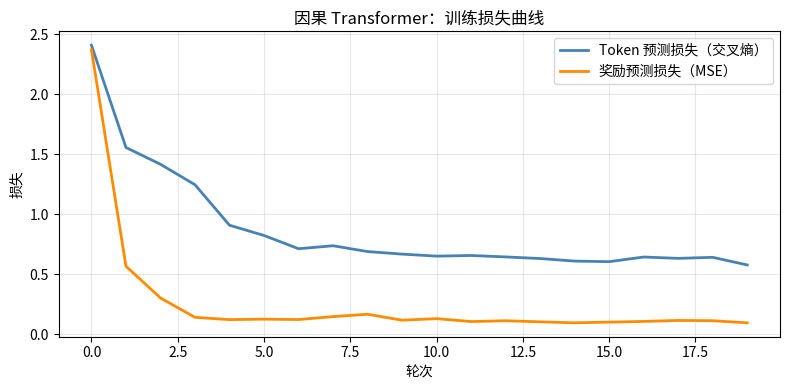

In [11]:
# --- 绘制 token 损失和奖励损失 ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(token_losses,  label='Token 预测损失（交叉熵）',  color='steelblue',  linewidth=2)
ax.plot(reward_losses, label='奖励预测损失（MSE）', color='darkorange', linewidth=2)
ax.set_xlabel('轮次')
ax.set_ylabel('损失')
ax.set_title('因果 Transformer：训练损失曲线')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Rollout 质量对比

对两种骨干网络解码 rollout，并按预测步数对比图像质量。

我们对比 RSSM（P02）和因果 Transformer 的想象 rollout。若 P02 的 `rssm.pt` 存在则直接加载；否则使用 P02 相同随机种子初始化 RSSM。两个模型从相同初始状态生成 10 步 rollout，并通过 CatVAE 解码器将预测的离散潜在还原为像素图像。PSNR 用于衡量各预测步数的像素级保真度。

In [12]:
# PSNR 工具函数。
def psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return 10 * torch.log10(1.0 / (mse + 1e-8))


# 与 P02 兼容的 RSSM，以便此处可以干净地加载保存的权重文件。
class RSSM(nn.Module):
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.action_dim = action_dim

        self.gru = nn.GRUCell(latent_dim + action_dim, hidden_dim)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _rsample(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def prior_step(self, z, h, a):
        if a.dim() == 1:
            a = a.unsqueeze(-1)
        h = self.gru(torch.cat([z, a.float()], dim=-1), h)
        pr = self.prior_net(h)
        mu, _ = pr.chunk(2, dim=-1)
        return mu, h

    def posterior_step(self, h, a, z_obs):
        if a.dim() == 1:
            a = a.unsqueeze(-1)
        po = self.post_net(torch.cat([h, z_obs], dim=-1))
        mu, logvar = po.chunk(2, dim=-1)
        z = self._rsample(mu, logvar)
        h = self.gru(torch.cat([z, a.float()], dim=-1), h)
        return z, h


# --- 加载或初始化 RSSM ---
rssm_path = next((p for p in [PATH / 'rssm.pt', PATH / 'notebooks' / 'rssm.pt'] if p.exists()), None)
if rssm_path is not None:
    try:
        state = torch.load(rssm_path, map_location=DEVICE)
        if isinstance(state, dict) and 'rssm_state_dict' in state:
            rssm = RSSM(
                latent_dim=int(state.get('latent_dim', 32)),
                action_dim=int(state.get('action_dim', 1)),
                hidden_dim=int(state.get('hidden_dim', 128)),
            ).to(DEVICE)
            rssm.load_state_dict(state['rssm_state_dict'])
            print(
                f"已从 {rssm_path} 加载 RSSM 权重 "
                f"(hidden_dim={rssm.hidden_dim}, latent_dim={rssm.latent_dim}, action_dim={rssm.action_dim})"
            )
        elif isinstance(state, dict) and 'rssm' in state:
            rssm = RSSM().to(DEVICE)
            rssm.load_state_dict(state['rssm'])
            print(f'已从 {rssm_path} 加载 RSSM 权重（旧版 rssm 键）')
        else:
            rssm = RSSM().to(DEVICE)
            rssm.load_state_dict(state)
            print(f'已从 {rssm_path} 加载 RSSM 权重（原始 state_dict）')
    except Exception as e:
        rssm = RSSM().to(DEVICE)
        print(f'无法加载 rssm.pt（{e}），使用随机初始化的 RSSM。')
else:
    rssm = RSSM().to(DEVICE)
    print('未找到 rssm.pt，使用随机初始化的 RSSM（P02 基线）。')

rssm.eval()
transformer_wm.eval()
catvae.eval()

已从 rssm.pt 加载 RSSM 权重 (hidden_dim=128, latent_dim=32, action_dim=1)


CatVAE(
  (encoder): CatVAEEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=4096, out_features=256, bias=True)
      (10): ReLU()
      (11): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): CatVAEDecoder(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4096, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
     

PSNR 工具已经准备好，下面按 rollout horizon 逐步评估，看看预测质量如何随时间衰减。

In [13]:
# 计算各预测步数的 PSNR。
ROLLOUT_LEN = 10
N_EVAL = 5  # 用于平均的轨迹数量

# 使用前 N_EVAL 条轨迹作为评估集
eval_obs  = obs_arr[:N_EVAL].to(DEVICE)   # (N_EVAL, T, 3, 64, 64)
eval_act  = act_arr[:N_EVAL].to(DEVICE)   # (N_EVAL, T)
eval_z    = z_encoded[:N_EVAL].to(DEVICE) # (N_EVAL, T, K)

horizons = [1, 3, 5, 10]
psnr_rssm_all  = {h: [] for h in horizons}
psnr_trans_all = {h: [] for h in horizons}

with torch.no_grad():
    for traj_i in range(N_EVAL):
        # 初始状态：编码第 0 步
        z0 = eval_z[traj_i, 0:1]         # (1, K)  one-hot
        acts = eval_act[traj_i]           # (T,)

        # ---- RSSM rollout ----
        z = z0.clone()
        h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
        rssm_preds = []  # 每步解码后的帧
        for t in range(ROLLOUT_LEN):
            a_t = acts[t:t+1].float().unsqueeze(-1)  # (1, 1)
            z, h = rssm.prior_step(z, h, a_t)
            frame = catvae.decoder(z)      # (1, 3, 64, 64)
            rssm_preds.append(frame)

        # ---- Transformer rollout ----
        # 以观测 z0 为起点，自回归预测
        z_seq = z0.unsqueeze(0)            # (1, 1, K)
        trans_preds = []
        for t in range(ROLLOUT_LEN):
            current_len = z_seq.shape[1]
            a_prefix = acts[:current_len].unsqueeze(0)  # (1, current_len)
            tok_logits, _, _ = transformer_wm(z_seq, a_prefix)  # (1, L, K)
            next_logits = tok_logits[:, -1, :]           # (1, K)
            next_z = F.one_hot(next_logits.argmax(-1), num_classes=NUM_CATEGORIES).float()  # (1, K)
            frame = catvae.decoder(next_z)               # (1, 3, 64, 64)
            trans_preds.append(frame)
            z_seq = torch.cat([z_seq, next_z.unsqueeze(1)], dim=1)  # (1, L+1, K)

        # 真实帧
        for h in horizons:
            if h <= ROLLOUT_LEN and h < eval_obs.shape[1]:
                gt = eval_obs[traj_i, h:h+1]             # (1, 3, 64, 64)
                p_rssm  = psnr(rssm_preds[h-1],  gt).item()
                p_trans = psnr(trans_preds[h-1], gt).item()
                psnr_rssm_all[h].append(p_rssm)
                psnr_trans_all[h].append(p_trans)

psnr_rssm_mean  = [np.mean(psnr_rssm_all[h])  for h in horizons]
psnr_trans_mean = [np.mean(psnr_trans_all[h]) for h in horizons]

print('各预测步数的 PSNR（dB）：')
print(f'{"预测步数":>10}  {"RSSM":>10}  {"Transformer":>12}')
for h, r, t in zip(horizons, psnr_rssm_mean, psnr_trans_mean):
    print(f'{h:>10}  {r:>10.2f}  {t:>12.2f}')

各预测步数的 PSNR（dB）：
      预测步数        RSSM   Transformer
         1       15.78         14.61
         3       18.34         14.63
         5       18.47         14.64
        10       18.42         14.64


分数收集完毕后，把它们画成 horizon 曲线，整体趋势会更容易读。

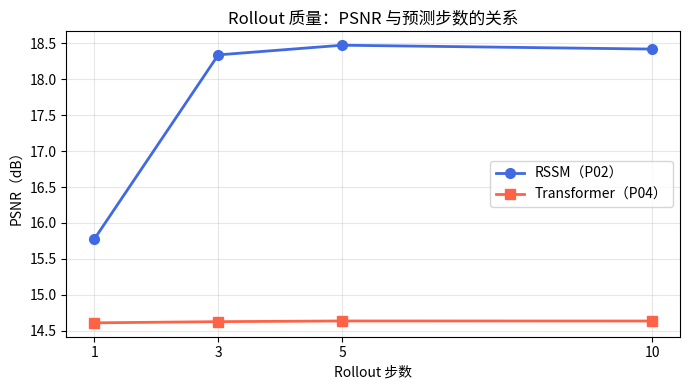

In [14]:
# --- 绘制 PSNR 与预测步数的关系 ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(horizons, psnr_rssm_mean,  'o-', color='royalblue',  linewidth=2, label='RSSM（P02）', markersize=7)
ax.plot(horizons, psnr_trans_mean, 's-', color='tomato',     linewidth=2, label='Transformer（P04）', markersize=7)
ax.set_xlabel('Rollout 步数')
ax.set_ylabel('PSNR（dB）')
ax.set_title('Rollout 质量：PSNR 与预测步数的关系')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

horizon 曲线先给出整体趋势，下面再用关键步的图像网格，把每一步的差异看得更具体。

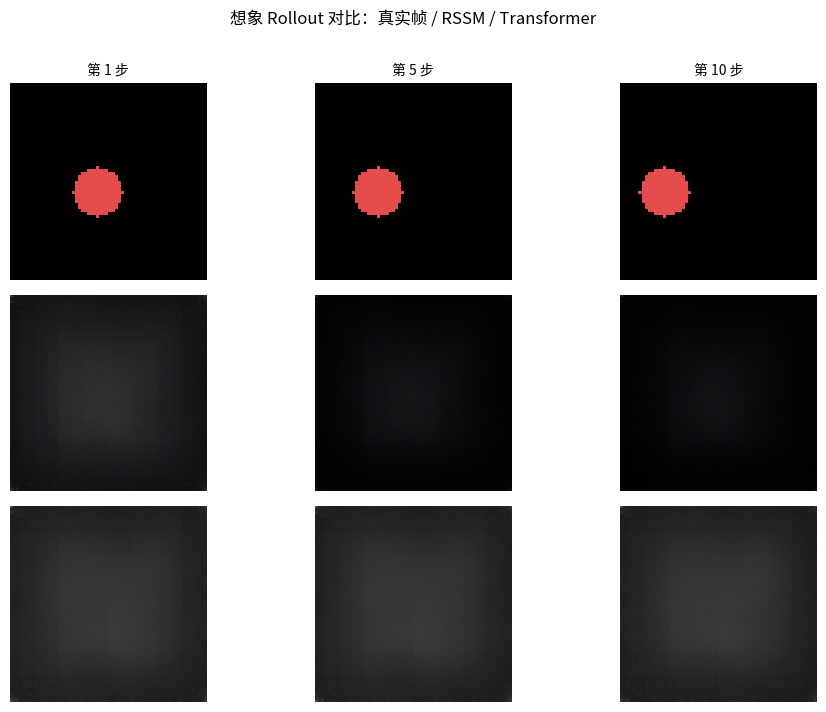

In [15]:
# 图像网格：真实帧 / RSSM / Transformer。
display_steps = [1, 5, 10]
traj_i = 0  # 使用第一条评估轨迹

with torch.no_grad():
    z0 = eval_z[traj_i, 0:1].to(DEVICE)
    acts = eval_act[traj_i].to(DEVICE)

    # RSSM rollout
    z = z0.clone()
    h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    rssm_frames = []
    for t in range(10):
        a_t = acts[t:t+1].float().unsqueeze(-1)
        z, h = rssm.prior_step(z, h, a_t)
        rssm_frames.append(catvae.decoder(z).cpu().squeeze(0))

    # Transformer rollout
    z_seq = z0.unsqueeze(0)
    trans_frames = []
    for t in range(10):
        current_len = z_seq.shape[1]
        a_prefix = acts[:current_len].unsqueeze(0)
        tok_logits, _, _ = transformer_wm(z_seq, a_prefix)
        next_z = F.one_hot(tok_logits[:, -1, :].argmax(-1), num_classes=NUM_CATEGORIES).float()
        trans_frames.append(catvae.decoder(next_z).cpu().squeeze(0))
        z_seq = torch.cat([z_seq, next_z.unsqueeze(1)], dim=1)

fig, axes = plt.subplots(3, len(display_steps), figsize=(10, 7))
row_labels = ['真实帧', 'RSSM（P02）', 'Transformer（P04）']
for col, step in enumerate(display_steps):
    gt_frame = eval_obs[traj_i, step].cpu().permute(1, 2, 0).numpy()
    rssm_frame = rssm_frames[step - 1].permute(1, 2, 0).numpy()
    trans_frame = trans_frames[step - 1].permute(1, 2, 0).numpy()
    for row, (frame, label) in enumerate(zip(
            [gt_frame, rssm_frame, trans_frame], row_labels)):
        ax = axes[row, col]
        ax.imshow(np.clip(frame, 0, 1))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=10)
        if row == 0:
            ax.set_title(f'第 {step} 步', fontsize=10)

plt.suptitle('想象 Rollout 对比：真实帧 / RSSM / Transformer', y=1.01)
plt.tight_layout()
plt.show()

## 5. 训练效率

选择动力学骨干网络时，实际训练耗时是一个重要的工程考量。此处将 Transformer 的每轮训练时间（已在上方记录）与 RSSM 的简短复跑结果进行对比，并绘制两种模型验证损失随累计训练时间的变化曲线。

In [16]:
# 简短的 RSSM 计时复跑。
class RSSMForTiming(nn.Module):
    """用于训练时间对比的精简 RSSM。"""
    def __init__(self, z_dim=NUM_CATEGORIES, a_dim=N_ACTIONS, h_dim=128):
        super().__init__()
        self.h_dim = h_dim
        self.a_embed = nn.Embedding(a_dim, 32)
        self.gru = nn.GRUCell(z_dim + 32, h_dim)
        self.prior = nn.Sequential(nn.Linear(h_dim, 128), nn.ELU(), nn.Linear(128, z_dim))
        self.post  = nn.Sequential(nn.Linear(h_dim + z_dim, 128), nn.ELU(), nn.Linear(128, z_dim))

    def forward(self, z_seq, a_seq):
        B, T, K = z_seq.shape
        h = torch.zeros(B, self.h_dim, device=z_seq.device)
        prior_logits, post_logits = [], []
        for t in range(T):
            a_emb = self.a_embed(a_seq[:, t])
            inp = torch.cat([z_seq[:, t], a_emb], -1)
            h = self.gru(inp, h)
            prior_logits.append(self.prior(h))
            post_logits.append(self.post(torch.cat([h, z_seq[:, t]], -1)))
        prior_logits = torch.stack(prior_logits, 1)  # (B, T, K)
        post_logits  = torch.stack(post_logits, 1)
        return prior_logits, post_logits

torch.manual_seed(42)
rssm_timing = RSSMForTiming().to(DEVICE)
opt_rssm = torch.optim.Adam(rssm_timing.parameters(), lr=1e-3)

RSSM_EPOCHS = 20
rssm_losses, rssm_times = [], []

print('正在进行 RSSM 计时对比训练...')
for epoch in range(RSSM_EPOCHS):
    t0 = time.time()
    ep_loss = 0.0
    for z_b, a_b, r_b, d_b in traj_loader:
        z_b = z_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        prior_logits, post_logits = rssm_timing(z_b, a_b)
        # KL + 重建损失
        target_idx = z_b[:, 1:, :].argmax(-1)          # (B, T-1)
        loss = F.cross_entropy(
            prior_logits[:, :-1, :].reshape(-1, NUM_CATEGORIES),
            target_idx.reshape(-1)
        )
        opt_rssm.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(rssm_timing.parameters(), 1.0)
        opt_rssm.step()
        ep_loss += loss.item()
    rssm_losses.append(ep_loss / len(traj_loader))
    rssm_times.append(time.time() - t0)
    if (epoch + 1) % 5 == 0:
        print(f'  轮次 {epoch+1:2d}/{RSSM_EPOCHS}  loss={rssm_losses[-1]:.4f}  耗时={rssm_times[-1]:.2f}s')

print(f'RSSM 平均每轮耗时：{np.mean(rssm_times):.3f}s')
print(f'Transformer 平均每轮耗时：{np.mean(epoch_times):.3f}s')

正在进行 RSSM 计时对比训练...
  轮次  5/20  loss=1.4906  耗时=0.17s
  轮次 10/20  loss=1.1873  耗时=0.18s
  轮次 15/20  loss=0.7329  耗时=0.17s
  轮次 20/20  loss=0.5095  耗时=0.17s
RSSM 平均每轮耗时：0.172s
Transformer 平均每轮耗时：0.080s


计时基线记录完毕后，再把验证损失和墙钟时间放在一起比较，把效率上的取舍说清楚。

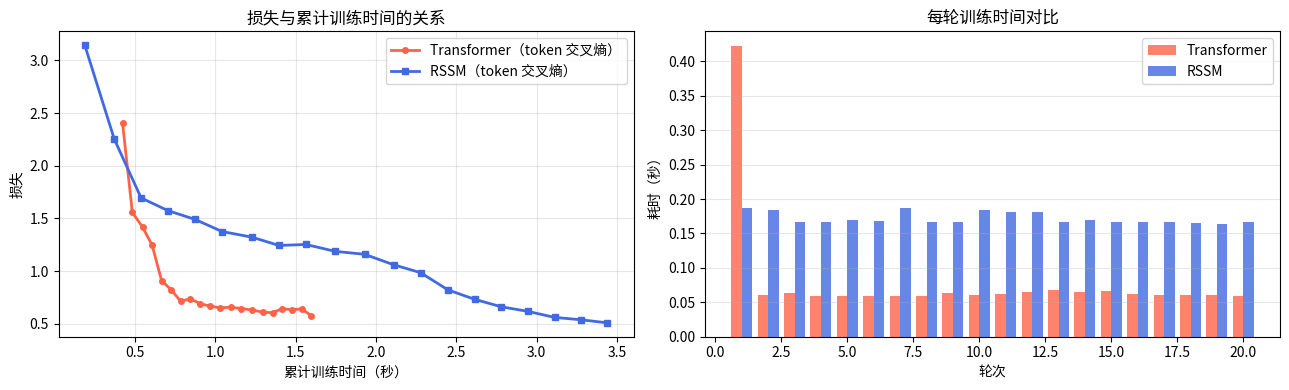

In [17]:
# 绘制验证损失与累计训练时间的关系。
trans_cumtime = np.cumsum(epoch_times)
rssm_cumtime  = np.cumsum(rssm_times)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左图：损失与累计训练时间
axes[0].plot(trans_cumtime, token_losses, 'o-', color='tomato',    linewidth=2, markersize=4, label='Transformer（token 交叉熵）')
axes[0].plot(rssm_cumtime,  rssm_losses,  's-', color='royalblue', linewidth=2, markersize=4, label='RSSM（token 交叉熵）')
axes[0].set_xlabel('累计训练时间（秒）')
axes[0].set_ylabel('损失')
axes[0].set_title('损失与累计训练时间的关系')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：每轮训练时间柱状图
x = np.arange(1, TRANS_EPOCHS + 1)
axes[1].bar(x - 0.2, epoch_times,  width=0.4, color='tomato',    label='Transformer', alpha=0.8)
axes[1].bar(x + 0.2, rssm_times,   width=0.4, color='royalblue', label='RSSM',        alpha=0.8)
axes[1].set_xlabel('轮次')
axes[1].set_ylabel('耗时（秒）')
axes[1].set_title('每轮训练时间对比')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 架构对比

RSSM 与 Transformer 在状态表示和计算方式上各有取舍。

| 属性 | RSSM（P02） | 因果 Transformer（P04） |
|---|---|---|
| **潜在表示** | 连续高斯分布（确定性 + 随机性） | 离散类别分布（Gumbel-softmax） |
| **序列处理** | 顺序 GRU，逐步展开 | 对全上下文窗口做并行注意力 |
| **梯度流** | 流经 GRU 隐状态 | 流经注意力权重 |
| **因果结构** | 隐式体现在 GRU 递推中 | 显式上三角因果掩码 |
| **长程记忆** | 随距离衰减（梯度消失） | 通过注意力在所有位置间保留 |
| **训练并行度** | 低：必须顺序展开 | 高：所有位置在一次前向中并行计算 |
| **参数量** | 较少（GRU 单元） | 较多（注意力层） |
| **典型每轮耗时** | 短序列上更快 | 较慢，但随序列变长扩展性更好 |

核心权衡在于归纳偏置与灵活性之间的取舍。RSSM 中的 GRU 天然具有近因效应和平滑潜在插值的特性，这在短时域预测任务上往往有帮助。Transformer 每步的计算代价更高，但能对上下文窗口中任意位置施加等同的注意力，这对存在长程依赖的任务至关重要（例如，许多步之前打开的门仍然影响智能体当前能做的事情）。

在实践中，STORM 风格的模型之所以选用 Transformer 作为动力学骨干网络，正是因为它随序列长度的扩展更为稳定可预期，且天然支持 token 级推理，与语言模型的范式高度一致。

In [18]:
# 保存模型权重。
save_path = PATH / 'transformer_wm.pt'
save_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'catvae': catvae.state_dict(),
    'transformer_wm': transformer_wm.state_dict(),
    'token_losses': token_losses,
    'reward_losses': reward_losses,
    'psnr_rssm': psnr_rssm_mean,
    'psnr_transformer': psnr_trans_mean,
    'horizons': horizons,
}, save_path)

print(f'已保存至 {save_path}')
print(f'  CatVAE 最终重建损失：              {vae_losses[-1]:.4f}')
print(f'  Transformer 最终 token 损失：       {token_losses[-1]:.4f}')
print(f'  Transformer 最终奖励损失：          {reward_losses[-1]:.4f}')
print(f'  RSSM 在第 10 步的 PSNR：            {psnr_rssm_mean[-1]:.2f} dB')
print(f'  Transformer 在第 10 步的 PSNR：     {psnr_trans_mean[-1]:.2f} dB')
print(f'  Transformer 总训练时间：            {trans_cumtime[-1]:.1f}s')
print(f'  RSSM 总训练时间：                   {rssm_cumtime[-1]:.1f}s')

已保存至 transformer_wm.pt
  CatVAE 最终重建损失：              0.0259
  Transformer 最终 token 损失：       0.5786
  Transformer 最终奖励损失：          0.0964
  RSSM 在第 10 步的 PSNR：            18.42 dB
  Transformer 在第 10 步的 PSNR：     14.64 dB
  Transformer 总训练时间：            1.6s
  RSSM 总训练时间：                   3.4s
